In [1]:
import re
import matplotlib.pyplot as plt

# Parse run.log
def plot_loss_from_log(log_path, ylim=None, xlim=None):
    epochs, val_losses, losses, lrs = [], [], [], []

    num_lines = 0
    with open(log_path, 'r') as f:
        lines = f.readlines()

    current_epoch = None

    # number pattern: optional sign, digits[.digits][exp]
    num_pat = r'([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)'

    for line in lines:
        num_lines += 1
        s = line.strip()

        # capture epoch number whenever it appears
        m_epoch = re.search(r'Epoch\s+(\d+)\s*/\s*\d+', s)
        if m_epoch:
            current_epoch = int(m_epoch.group(1))

        # look for the summary line that carries loss/val_loss/lr
        if "MinusLogProbMetric:" in s and "val_loss:" in s:
            m_val  = re.search(rf'val_loss:\s*{num_pat}', s)
            m_loss = re.search(rf'loss:\s*{num_pat}', s)
            m_lr   = re.search(rf'lr:\s*{num_pat}', s)

            # only record a point if we have epoch + both losses
            if current_epoch is not None and m_val and m_loss:
                epochs.append(current_epoch)
                val_losses.append(float(m_val.group(1)))
                losses.append(float(m_loss.group(1)))
                lrs.append(float(m_lr.group(1)) if m_lr else (lrs[-1] if lrs else None))
            # else: skip the line; don't append lr alone (keeps arrays aligned)

    if not val_losses:
        raise ValueError("No epochs parsed — check the log format or regex.")

    print(val_losses)
    print("minimum validation loss:", min(val_losses))
    print("minimum training loss:", min(losses))

    fig, ax1 = plt.subplots()
    ax1.plot(epochs, val_losses, label='val loss')
    ax1.plot(epochs, losses,     label='train loss')
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss (log scale)")
    ax1.set_yscale('symlog', linthresh=1e-3)  # show both signs; linear near 0
    ax1.grid(True, which="both", ls="--", lw=0.5)
    if ylim is not None: ax1.set_ylim(ylim)
    if xlim is not None: ax1.set_xlim(xlim)

    ax2 = ax1.twinx()
    ax2.plot(epochs, lrs, linestyle='-', label='learning rate', color='limegreen')
    ax2.set_ylabel("Learning Rate")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

    print(min(lrs), max(lrs), lrs.index(min(lrs)), lrs.index(max(lrs)))
    print("first lr value:", lrs[0], lrs[1])

    plt.title("Training & Validation Loss ↔ Learning Rate")
    plt.tight_layout()
    plt.show()


# 40

[24.036575, 24.0366, 14.004388, 14.0044, 11.391165, 11.3912, 10.60828, 10.6083, 9.859855, 9.8599, 9.558585, 9.5586, 8.89621, 8.8962, 8.605588, 8.6056, 8.661511, 8.6615, 8.249, 8.249, 8.402822, 8.4028, 9.623268, 9.6233, 9.71128, 9.7113, 7.616091, 7.6161, 7.367822, 7.3678, 7.492533, 7.4925, 11.378316, 11.3783, 7.780788, 7.7808, 8.112963, 8.113, 7.183554, 7.1836, 7.244198, 7.2442, 7.363004, 7.363, 7.331719, 7.3317, 7.322939, 7.3229, 6.225587, 6.2256, 6.628261, 6.6283, 6.884095, 6.8841, 6.934859, 6.9349, 7.492487, 7.4925, 6.259413, 6.2594, 6.039436, 6.0394, 5.953401, 5.9534, 5.88838, 5.8884, 4.81222, 4.8122, 5.675135, 5.6751, 6.177478, 6.1775, 5.353286, 5.3533, 4.825475, 4.8255, 5.233221, 5.2332, 4.388577, 4.3886, 4.106015, 4.106, 5.43618, 5.4362, 3.96652, 3.9665, 4.823541, 4.8235, 3.962635, 3.9626, 4.789743, 4.7897, 3.3161, 3.3161, 3.715755, 3.7158, 3.338003, 3.338, 3.242531, 3.2425, 3.57711, 3.5771, 2.96513, 2.9651, 2.404242, 2.4042, 2.793861, 2.7939, 2.542828, 2.5428, 2.822371, 2.8224, 

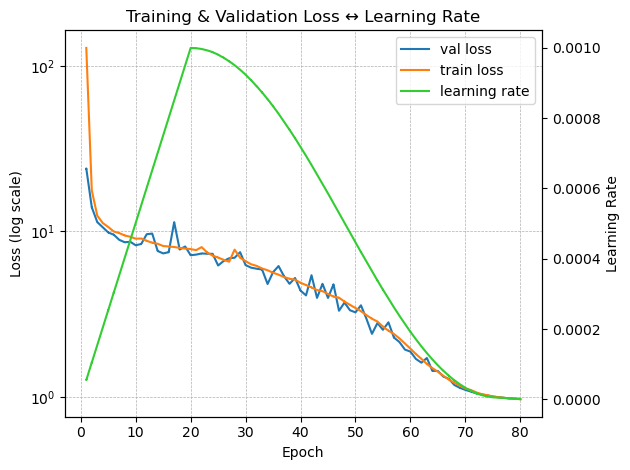

In [2]:
plot_loss_from_log('outputs/run_40/10k_events_run.log')

# 47

[25.073004, 25.073, 15.543377, 15.5434, 12.904315, 12.9043, 12.380716, 12.3807, 10.806022, 10.806, 10.30444, 10.3044, 10.003712, 10.0037, 10.029096, 10.0291, 9.497706, 9.4977, 9.088471, 9.0885, 9.722581, 9.7226, 9.00046, 9.0005, 8.7454, 8.7454, 8.844718, 8.8447, 11.328283, 11.3283, 11.015638, 11.0156, 9.584127, 9.5841, 9.756953, 9.757, 8.171843, 8.1718, 7.566403, 7.5664, 8.049945, 8.0499, 7.461909, 7.4619, 7.635721, 7.6357, 11.211351, 11.2114, 9.452402, 9.4524, 7.609699, 7.6097, 8.271264, 8.2713, 7.369394, 7.3694, 7.883035, 7.883, 7.049353, 7.0494, 6.662238, 6.6622, 10.256597, 10.2566, 7.073336, 7.0733, 7.546983, 7.547, 8.031368, 8.0314, 6.609569, 6.6096, 6.474638, 6.4746, 6.828867, 6.8289, 6.905269, 6.9053, 5.737591, 5.7376, 5.900866, 5.9009, 7.097625, 7.0976, 5.139859, 5.1399, 5.443734, 5.4437, 5.922613, 5.9226, 7.011536, 7.0115, 4.84714, 4.8471, 5.738445, 5.7384, 4.088356, 4.0884, 4.402446, 4.4024, 3.911853, 3.9119, 4.178534, 4.1785, 3.533263, 3.5333, 3.557266, 3.5573, 4.107071, 4.1

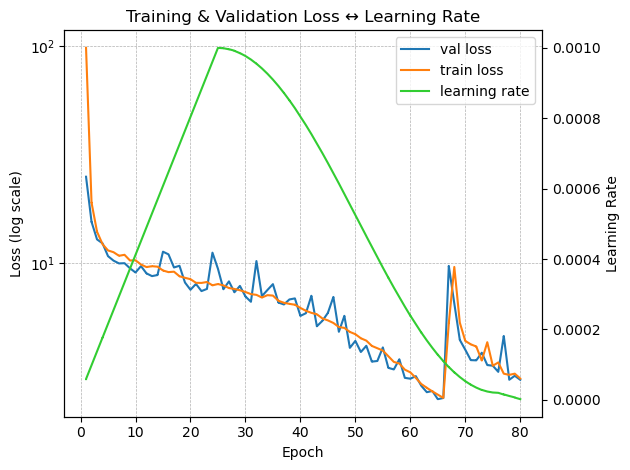

In [3]:
plot_loss_from_log('outputs/run_47/10k_events_run.log')

# 48

[29.64348, 29.6435, 16.319548, 16.3195, 13.296795, 13.2968, 11.848404, 11.8484, 10.755384, 10.7554, 10.804474, 10.8045, 10.415581, 10.4156, 9.364655, 9.3647, 9.142854, 9.1429, 9.302979, 9.303, 9.116071, 9.1161, 8.857572, 8.8576, 9.17692, 9.1769, 8.469714, 8.4697, 10.135362, 10.1354, 8.385691, 8.3857, 8.238012, 8.238, 7.981996, 7.982, 8.23449, 8.2345, 7.84008, 7.8401, 7.692832, 7.6928, 7.722664, 7.7227, 7.511029, 7.511, 10.251365, 10.2514, 7.122682, 7.1227, 8.107472, 8.1075, 7.386998, 7.387, 6.819298, 6.8193, 7.575761, 7.5758, 7.934238, 7.9342, 8.155298, 8.1553, 6.282138, 6.2821, 8.775492, 8.7755, 6.250912, 6.2509, 5.838066, 5.8381, 7.941621, 7.9416, 6.871961, 6.872, 5.437275, 5.4373, 6.621448, 6.6214, 5.218307, 5.2183, 5.822593, 5.8226, 5.058315, 5.0583, 5.203995, 5.204, 5.765256, 5.7653, 5.406957, 5.407, 4.899873, 4.8999, 4.487774, 4.4878, 4.664535, 4.6645, 6.361108, 6.3611, 4.147674, 4.1477, 4.060351, 4.0604, 4.473241, 4.4732, 3.50965, 3.5096, 4.960479, 4.9605, 3.40311, 3.4031, 3.182

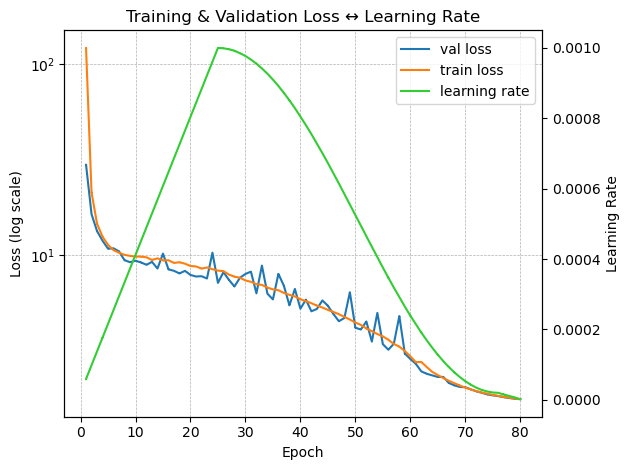

In [4]:
plot_loss_from_log('outputs/run_48/full_run_48.log')

# 49

[14.391539, 14.3915, 10.902454, 10.9025, 9.719839, 9.7198, 9.127633, 9.1276, 8.30878, 8.3088, 9.514323, 9.5143, 7.900275, 7.9003, 7.182585, 7.1826, 7.018938, 7.0189, 6.543153, 6.5432, 9.038301, 9.0383, 10.065085, 10.0651, 7.686169, 7.6862, 6.802178, 6.8022, 6.173693, 6.1737, 6.40823, 6.4082, 5.456093, 5.4561, 5.828908, 5.8289, 6.000987, 6.001, 5.501187, 5.5012, 6.377649, 6.3776, 5.439812, 5.4398, 5.372129, 5.3721, 4.740288, 4.7403, 5.143942, 5.1439, 4.708363, 4.7084, 4.882809, 4.8828, 4.81225, 4.8122, 4.232093, 4.2321, 5.256252, 5.2563, 4.319506, 4.3195, 4.076306, 4.0763, 3.818035, 3.818, 3.781426, 3.7814, 3.667555, 3.6676, 4.256689, 4.2567, 4.306831, 4.3068, 3.658052, 3.6581, 4.555979, 4.556, 2.914345, 2.9143, 3.696652, 3.6967, 4.007392, 4.0074, 3.554277, 3.5543, 3.454063, 3.4541, 3.655068, 3.6551, 2.537222, 2.5372, 2.403491, 2.4035, 2.786356, 2.7864, 2.644003, 2.644, 2.2247, 2.2247, 1.983594, 1.9836, 2.235293, 2.2353, 2.578833, 2.5788, 1.586502, 1.5865, 1.908383, 1.9084, 1.243141, 1.

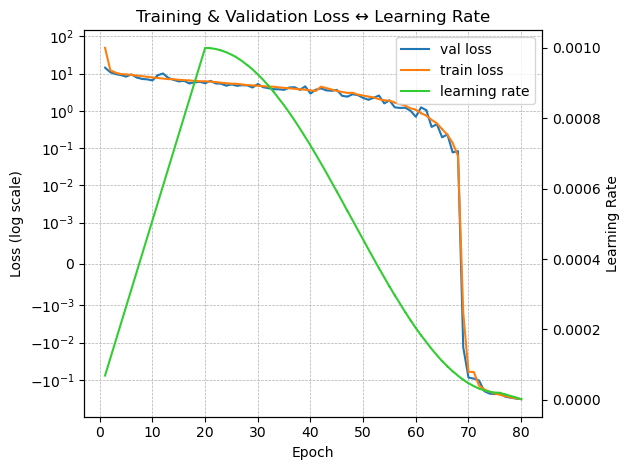

In [5]:
plot_loss_from_log('outputs/run_49/full_run_49.log')

# 50 


[16.352573, 16.3526, 10.881806, 10.8818, 9.475128, 9.4751, 8.715897, 8.7159, 10.308641, 10.3086, 8.273769, 8.2738, 7.526819, 7.5268, 8.129275, 8.1293, 8.455315, 8.4553, 9.158543, 9.1585, 9.747258, 9.7473, 8.539407, 8.5394, 5.859747, 5.8597, 8.127145, 8.1271, 5.92767, 5.9277, 9.275245, 9.2752, 7.71915, 7.7191, 6.503493, 6.5035, 6.896438, 6.8964, 6.991844, 6.9918, 5.579835, 5.5798, 4.741702, 4.7417, 5.022453, 5.0225, 4.473976, 4.474, 5.795978, 5.796, 5.983714, 5.9837, 4.586193, 4.5862, 4.676436, 4.6764, 5.722331, 5.7223, 5.228602, 5.2286, 3.869782, 3.8698, 4.762639, 4.7626, 4.219698, 4.2197, 3.572754, 3.5728, 4.206568, 4.2066, 5.414845, 5.4148, 5.66487, 5.6649, 4.483885, 4.4839, 4.363385, 4.3634, 4.632147, 4.6321, 3.494901, 3.4949, 3.726201, 3.7262, 4.021654, 4.0217, 3.463635, 3.4636, 2.914342, 2.9143, 3.656948, 3.6569, 2.813347, 2.8133, 2.80546, 2.8055, 2.643789, 2.6438, 2.182321, 2.1823, 2.14968, 2.1497, 1.833235, 1.8332, 2.312042, 2.312, 1.627769, 1.6278, 1.275608, 1.2756, 1.127068, 1

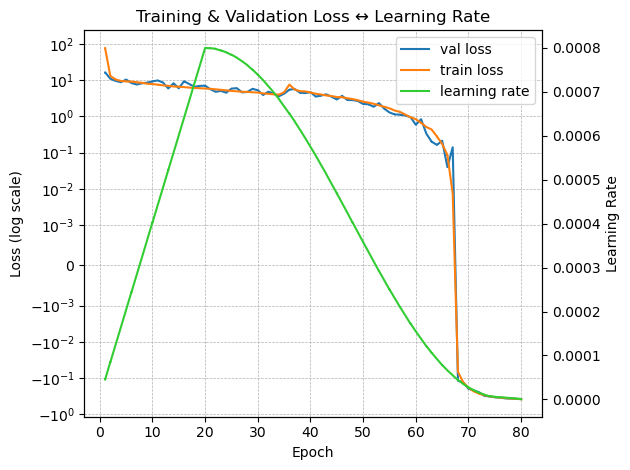

In [6]:
plot_loss_from_log('outputs/run_50/full_run_50.log')

# 51

[17.885141, 17.8851, 12.182855, 12.1829, 12.934245, 12.9342, 8.988716, 8.9887, 8.437286, 8.4373, 7.867308, 7.8673, 9.191219, 9.1912, 7.229086, 7.2291, 7.423798, 7.4238, 7.619573, 7.6196, 7.683975, 7.684, 7.870683, 7.8707, 7.978071, 7.9781, 6.226558, 6.2266, 6.161559, 6.1616, 6.655792, 6.6558, 5.61351, 5.6135, 5.592199, 5.5922, 5.556061, 5.5561, 4.995824, 4.9958, 5.104848, 5.1048, 5.465118, 5.4651, 4.644918, 4.6449, 4.633655, 4.6337, 5.134374, 5.1344, 4.890118, 4.8901, 4.589572, 4.5896, 4.449875, 4.4499, 3.694452, 3.6945, 3.863547, 3.8635, 4.236523, 4.2365, 3.766844, 3.7668, 3.737297, 3.7373, 3.541212, 3.5412, 3.460289, 3.4603, 3.188302, 3.1883, 3.014873, 3.0149, 3.59242, 3.5924, 2.649601, 2.6496, 3.292008, 3.292, 5.084518, 5.0845, 3.484266, 3.4843, 3.060667, 3.0607, 3.001551, 3.0016, 2.335279, 2.3353, 2.830505, 2.8305, 2.11425, 2.1142, 2.092562, 2.0926, 1.685764, 1.6858, 1.830366, 1.8304, 1.585919, 1.5859, 1.259065, 1.2591, 1.116923, 1.1169, 1.531154, 1.5312, 1.922319, 1.9223, 0.885509

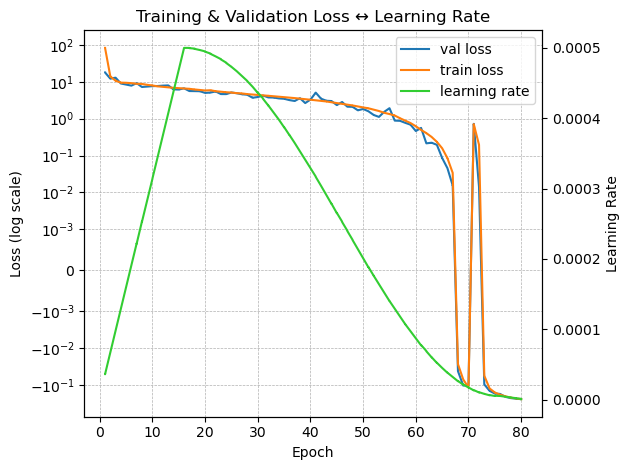

In [7]:
plot_loss_from_log('outputs/run_51/full_run_51.log')

# 52

[14.034615, 14.0346, 10.658864, 10.6589, 9.304539, 9.3045, 9.793609, 9.7936, 8.248342, 8.2483, 7.878794, 7.8788, 10.770303, 10.7703, 7.027634, 7.0276, 7.251855, 7.2519, 7.13047, 7.1305, 6.904281, 6.9043, 6.55221, 6.5522, 6.685447, 6.6854, 5.706735, 5.7067, 6.44976, 6.4498, 5.762404, 5.7624, 6.068053, 6.0681, 7.901065, 7.9011, 5.370166, 5.3702, 6.020455, 6.0205, 5.412754, 5.4128, 7.490396, 7.4904, 5.70088, 5.7009, 6.174583, 6.1746, 6.319066, 6.3191, 4.92081, 4.9208, 5.065007, 5.065, 5.558508, 5.5585, 4.57588, 4.5759, 4.774977, 4.775, 4.345521, 4.3455, 4.941682, 4.9417, 4.210414, 4.2104, 6.018859, 6.0189, 4.213602, 4.2136, 4.374955, 4.375, 3.568389, 3.5684, 4.339823, 4.3398, 3.044982, 3.045, 4.450111, 4.4501, 3.231057, 3.2311, 5.198972, 5.199, 7.136071, 7.1361, 3.40335, 3.4033, 3.902182, 3.9022, 2.49346, 2.4935, 2.824683, 2.8247, 2.172629, 2.1726, 2.59294, 2.5929, 1.984382, 1.9844, 2.035391, 2.0354, 2.244985, 2.245, 2.313956, 2.314, 1.881999, 1.882, 1.058266, 1.0583, 2.167244, 2.1672, 1.

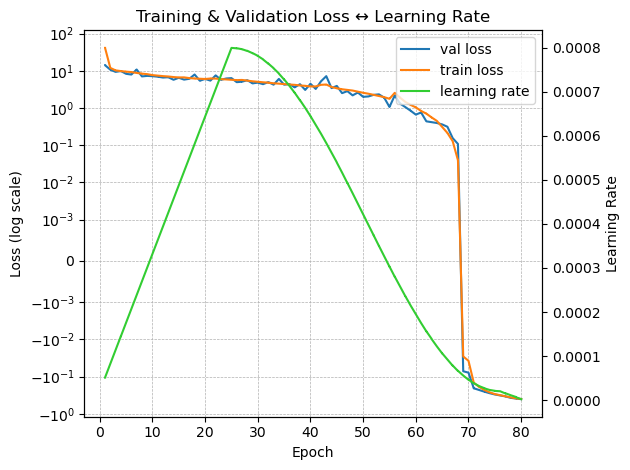

In [8]:
plot_loss_from_log('outputs/run_52/full_run_52.log')

# 53 Best, batchsize = 10k
- warmup_epochs       = 30
- cooldown_epochs     = 46
- annihilation_epochs = 4
- max_lr              = 8e-4
- base_lr             = 1e-5


[16.109902, 16.1099, 11.207374, 11.2074, 9.553039, 9.553, 8.697681, 8.6977, 9.745447, 9.7454, 9.183562, 9.1836, 7.745572, 7.7456, 8.469869, 8.4699, 7.959788, 7.9598, 7.620607, 7.6206, 6.538435, 6.5384, 9.273591, 9.2736, 8.492549, 8.4925, 6.524812, 6.5248, 8.257719, 8.2577, 5.975355, 5.9754, 6.128971, 6.129, 6.6848, 6.6848, 5.538975, 5.539, 6.020598, 6.0206, 5.290814, 5.2908, 6.824732, 6.8247, 5.144906, 5.1449, 5.444932, 5.4449, 5.20785, 5.2079, 4.771344, 4.7713, 6.473803, 6.4738, 4.769134, 4.7691, 4.753157, 4.7532, 4.598098, 4.5981, 4.604832, 4.6048, 5.834968, 5.835, 5.283236, 5.2832, 5.273307, 5.2733, 4.192283, 4.1923, 4.832491, 4.8325, 3.839208, 3.8392, 4.750859, 4.7509, 4.134959, 4.135, 3.894402, 3.8944, 3.331162, 3.3312, 4.633106, 4.6331, 5.078298, 5.0783, 2.845891, 2.8459, 3.082466, 3.0825, 2.718671, 2.7187, 3.169285, 3.1693, 2.637951, 2.638, 2.602052, 2.6021, 2.690992, 2.691, 2.582584, 2.5826, 2.15971, 2.1597, 2.562263, 2.5623, 3.065418, 3.0654, 2.279028, 2.279, 1.463563, 1.4636,

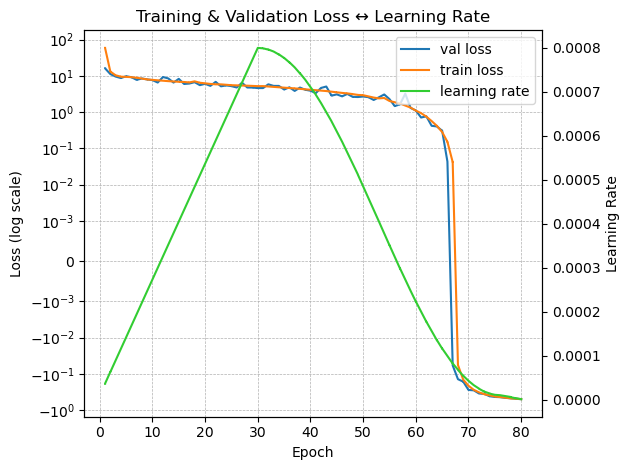

In [9]:
plot_loss_from_log('outputs/run_53/full_run_53.log')

# 54


[18.798383, 18.7984, 11.925146, 11.9251, 9.934184, 9.9342, 9.241721, 9.2417, 8.451528, 8.4515, 8.017182, 8.0172, 7.717163, 7.7172, 7.311659, 7.3117, 7.768483, 7.7685, 7.56583, 7.5658, 6.44914, 6.4491, 7.22112, 7.2211, 6.230106, 6.2301, 6.517275, 6.5173, 6.394421, 6.3944, 5.961425, 5.9614, 5.881828, 5.8818, 5.62965, 5.6297, 7.717123, 7.7171, 5.374916, 5.3749, 5.472328, 5.4723, 6.565166, 6.5652, 5.900397, 5.9004, 4.825143, 4.8251, 5.747494, 5.7475, 7.311565, 7.3116, 6.609099, 6.6091, 4.794991, 4.795, 5.330776, 5.3308, 4.288405, 4.2884, 5.478537, 5.4785, 4.666389, 4.6664, 4.321413, 4.3214, 4.518971, 4.519, 4.076378, 4.0764, 3.681912, 3.6819, 4.068359, 4.0684, 4.036541, 4.0365, 6.837843, 6.8378, 3.523783, 3.5238, 3.189894, 3.1899, 3.605278, 3.6053, 3.885502, 3.8855, 3.226678, 3.2267, 3.110673, 3.1107, 3.621364, 3.6214, 4.044725, 4.0447, 2.877403, 2.8774, 2.480843, 2.4808, 3.556588, 3.5566, 2.09063, 2.0906, 2.414004, 2.414, 1.58645, 1.5865, 2.488283, 2.4883, 2.406381, 2.4064, 1.385536, 1.38

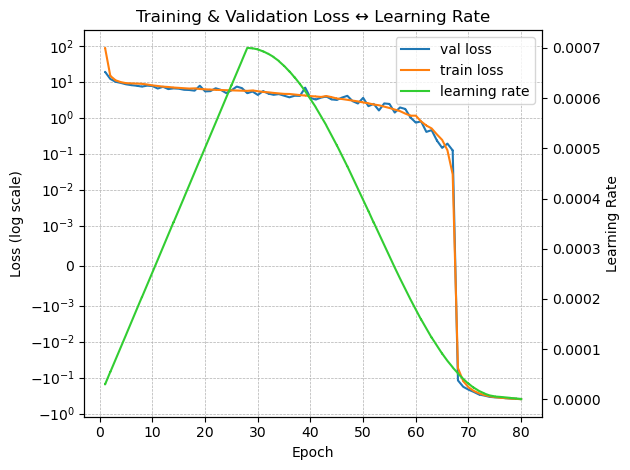

In [10]:
plot_loss_from_log('outputs/run_54/full_run_54.log')

# 55, Supercalo B, killed bad results 
- warmup_epochs       = 28
- cooldown_epochs     = 48
- annihilation_epochs = 4
- max_lr              = 7e-4
- base_lr             = 5e-6

[21.726746, 21.7267, 16.167087, 16.1671, 14.586617, 14.5866, 18.057648, 18.0576, 14.740941, 14.7409, 19.343288, 19.3433, 13.15595, 13.156, 13.060523, 13.0605, 13.994335, 13.9943, 13.802481, 13.8025, 12.48673, 12.4867, 12.542304, 12.5423, 12.441996, 12.442, 13.580102, 13.5801, 12.129686, 12.1297, 11.968949, 11.9689, 11.894595, 11.8946, 11.827046, 11.827, 12.520962, 12.521, 11.886995, 11.887, 11.732321, 11.7323, 11.909382, 11.9094, 11.737317, 11.7373, 11.533947, 11.5339, 12.622868, 12.6229, 11.523397, 11.5234, 11.778006, 11.778, 11.705946, 11.7059, 11.310027, 11.31, 11.407226, 11.4072, 11.608577, 11.6086, 12.390843, 12.3908, 11.004525, 11.0045, 11.441164, 11.4412, 11.39265, 11.3927, 11.268717, 11.2687, 11.087218, 11.0872, 11.055568, 11.0556, 11.194731, 11.1947, 15.16313, 15.1631, 11.790832, 11.7908, 11.381078, 11.3811, 11.290013, 11.29, 10.930516, 10.9305, 11.630588, 11.6306, 10.624656, 10.6247, 11.063317, 11.0633, 11.969542, 11.9695, 10.880873, 10.8809, 10.264639, 10.2646, 10.310682, 10

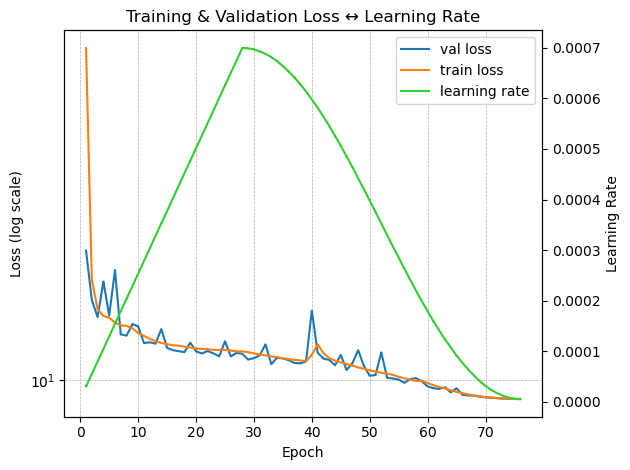

In [11]:
plot_loss_from_log('outputs/run_55/full_B_run.log')

# 56 supercalo A senza fine layer energies, killed bad results 
- warmup_epochs       = 28
- cooldown_epochs     = 48
- annihilation_epochs = 4
- max_lr              = 7e-4
- base_lr             = 5e-6

[17.485488, 17.4855, 13.286746, 13.2867, 13.450203, 13.4502, 11.819174, 11.8192, 11.86364, 11.8636, 11.27025, 11.2702, 11.702092, 11.7021, 14.152185, 14.1522, 12.567562, 12.5676, 10.501469, 10.5015, 10.363965, 10.364, 11.350046, 11.35, 10.047359, 10.0474, 12.032429, 12.0324, 11.659151, 11.6592, 10.17824, 10.1782, 9.979783, 9.9798, 9.560558, 9.5606, 10.018784, 10.0188, 9.721095, 9.7211, 9.938354, 9.9384, 9.736874, 9.7369, 9.71867, 9.7187, 9.302044, 9.302, 9.220035, 9.22, 9.86119, 9.8612, 11.104664, 11.1047, 9.638687, 9.6387, 9.707105, 9.7071, 10.084618, 10.0846, 10.094867, 10.0949, 9.777844, 9.7778, 9.249816, 9.2498, 8.980947, 8.9809, 9.232756, 9.2328, 8.909051, 8.9091, 8.574499, 8.5745, 8.540788, 8.5408, 8.984153, 8.9842, 8.358554, 8.3586, 8.373809, 8.3738, 8.355637, 8.3556, 8.727562, 8.7276, 8.237738, 8.2377, 8.511101, 8.5111, 8.040486, 8.0405, 8.903818, 8.9038, 8.123698, 8.1237, 10.014174, 10.0142, 8.071977, 8.072, 10.275797, 10.2758, 7.67157, 7.6716, 7.852656, 7.8527, 8.479614, 8.47

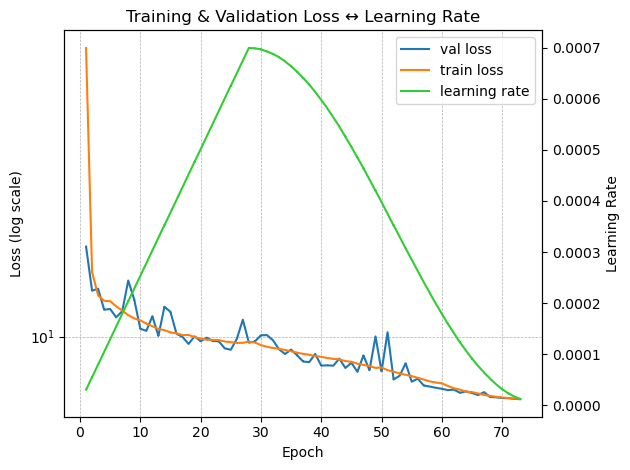

In [12]:
plot_loss_from_log('outputs/run_56/full_A_run.log')

# 57 RealNVP test, inspiegabilmente stoppato. magari qualcuno ha interrotto il porcesso perche serviva GPU?
- warmup_epochs       = 28
- cooldown_epochs     = 48
- annihilation_epochs = 4
- max_lr              = 7e-4
- base_lr             = 5e-6

[26.178821, 26.1788, 18.359121, 18.3591, 15.510999, 15.511, 14.081124, 14.0811, 13.614089, 13.6141, 12.612133, 12.6121, 12.415073, 12.4151, 11.863494, 11.8635, 11.111291, 11.1113, 10.721994, 10.722, 10.545045, 10.545, 10.322519, 10.3225, 10.332658, 10.3327, 10.260195, 10.2602, 9.846548, 9.8465, 10.023437, 10.0234, 9.595642, 9.5956, 9.375118, 9.3751, 9.880243, 9.8802, 9.194827, 9.1948, 9.528789, 9.5288, 10.021041, 10.021, 9.400933, 9.4009, 9.041978, 9.042, 8.914117, 8.9141, 8.357722, 8.3577, 15.435224, 15.4352, 11.61618, 11.6162, 10.405822, 10.4058, 9.633635, 9.6336, 9.213522, 9.2135, 8.812768, 8.8128, 8.369563, 8.3696, 8.960767, 8.9608, 7.580632, 7.5806, 7.446146, 7.4461, 7.319351, 7.3194, 6.963487, 6.9635, 6.99636, 6.9964, 7.095987, 7.096, 6.739182, 6.7392, 7.541778, 7.5418, 6.581375, 6.5814, 6.65321, 6.6532, 6.75185, 6.7518, 5.939953, 5.94, 5.797459, 5.7975, 6.675528, 6.6755, 6.024625, 6.0246, 5.330592, 5.3306]
minimum validation loss: 5.330592
minimum training loss: 5.6668
2.9821e-0

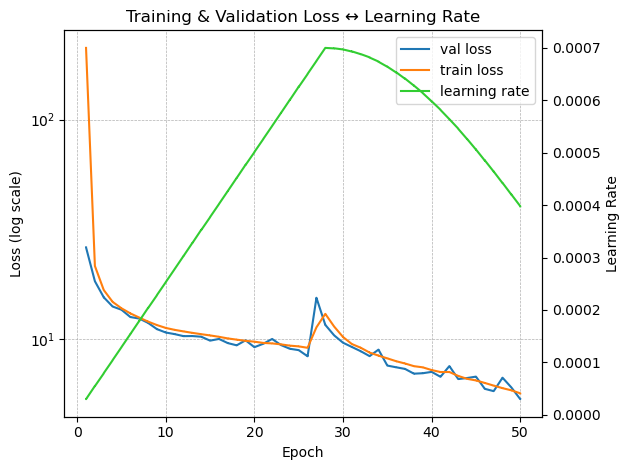

In [13]:
plot_loss_from_log('outputs/run_57/full_RealNVP_run.log')

# 59 Supercalo B. Stessi parametri del migliore run ottenuto fino a questo momento 
- warmup_epochs       = 30
- cooldown_epochs     = 46
- annihilation_epochs = 4
- max_lr              = 8e-4
- base_lr             = 1e-5


[19.915809, 19.9158, 15.464297, 15.4643, 14.306544, 14.3065, 13.73236, 13.7324, 13.621492, 13.6215, 13.448859, 13.4489, 13.354449, 13.3544, 13.064296, 13.0643, 12.940242, 12.9402, 12.776647, 12.7766, 12.490715, 12.4907, 13.922396, 13.9224, 12.688345, 12.6883, 12.298582, 12.2986, 11.963085, 11.9631, 12.059282, 12.0593, 11.950014, 11.95, 14.614783, 14.6148, 11.568278, 11.5683, 11.771217, 11.7712, 11.543888, 11.5439, 11.6736, 11.6736, 12.157989, 12.158, 11.570695, 11.5707, 11.395282, 11.3953, 11.485768, 11.4858, 11.378802, 11.3788, 12.124419, 12.1244, 11.440253, 11.4403, 11.285998, 11.286, 11.849976, 11.85, 12.015207, 12.0152, 11.551773, 11.5518, 11.430002, 11.43, 11.332648, 11.3326, 12.515929, 12.5159, 13.231904, 13.2319, 10.895719, 10.8957, 10.896961, 10.897, 11.467379, 11.4674, 11.093078, 11.0931, 11.144194, 11.1442, 12.102838, 12.1028, 10.599212, 10.5992, 10.616779, 10.6168, 10.574109, 10.5741, 11.135092, 11.1351, 10.32643, 10.3264, 10.244226, 10.2442, 10.324155, 10.3242, 10.344075, 1

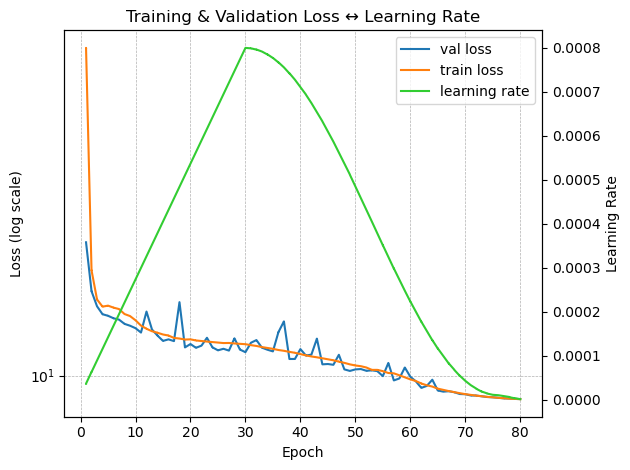

In [14]:
plot_loss_from_log('outputs/run_59/full_B_run.log')

# 60 Supercalo A senza fine layer energies. 
- warmup_epochs       = 30
- cooldown_epochs     = 46
- annihilation_epochs = 4
- max_lr              = 8e-4
- base_lr             = 1e-5

[15.977511, 15.9775, 12.85919, 12.8592, 12.172295, 12.1723, 11.781769, 11.7818, 11.847845, 11.8478, 12.285713, 12.2857, 14.71317, 14.7132, 11.093897, 11.0939, 10.714619, 10.7146, 10.410578, 10.4106, 10.731965, 10.732, 10.212261, 10.2123, 9.911813, 9.9118, 10.259064, 10.2591, 10.160926, 10.1609, 9.642806, 9.6428, 11.047131, 11.0471, 9.777422, 9.7774, 9.871853, 9.8719, 12.52722, 12.5272, 10.434634, 10.4346, 9.702511, 9.7025, 10.486364, 10.4864, 9.335711, 9.3357, 9.299936, 9.2999, 9.259674, 9.2597, 9.076581, 9.0766, 10.13755, 10.1376, 9.692013, 9.692, 9.323171, 9.3232, 9.309062, 9.3091, 8.953702, 8.9537, 10.793218, 10.7932, 9.084141, 9.0841, 9.145595, 9.1456, 8.654314, 8.6543, 8.654075, 8.6541, 10.512779, 10.5128, 8.583938, 8.5839, 9.027546, 9.0275, 8.57333, 8.5733, 8.271116, 8.2711, 8.381539, 8.3815, 9.245326, 9.2453, 8.312543, 8.3125, 8.247316, 8.2473, 8.519423, 8.5194, 8.123465, 8.1235, 7.992381, 7.9924, 7.852031, 7.852, 8.31934, 8.3193, 8.341976, 8.342, 7.784163, 7.7842, 7.7509, 7.750

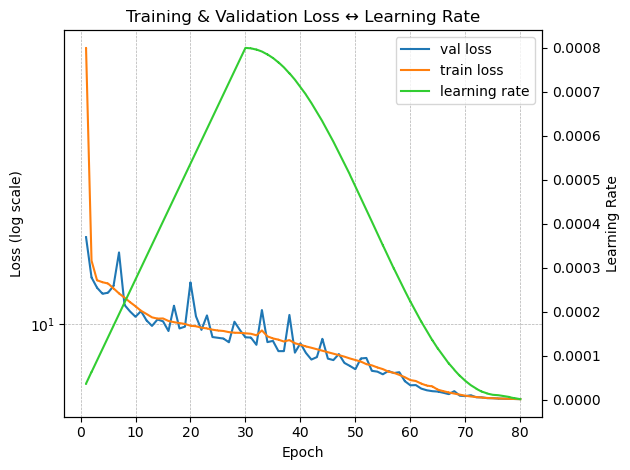

In [15]:
plot_loss_from_log('outputs/run_60/full_A_run.log')

# 61, Supercalo A senza fine layer energies. 
- warmup_epochs       = 35
- cooldown_epochs     = 41
- annihilation_epochs = 4
- max_lr              = 8e-4
- base_lr             = 8e-6

[16.935032, 16.935, 13.163363, 13.1634, 12.292875, 12.2929, 11.856101, 11.8561, 11.547723, 11.5477, 11.252676, 11.2527, 12.476255, 12.4763, 11.285068, 11.2851, 10.723468, 10.7235, 11.118682, 11.1187, 10.945342, 10.9453, 10.170684, 10.1707, 10.304865, 10.3049, 10.074864, 10.0749, 11.394009, 11.394, 10.259449, 10.2594, 9.907631, 9.9076, 10.112672, 10.1127, 10.671785, 10.6718, 10.074471, 10.0745, 10.428766, 10.4288, 9.391689, 9.3917, 9.704165, 9.7042, 9.399871, 9.3999, 9.330434, 9.3304, 11.166535, 11.1665, 10.141124, 10.1411, 9.62091, 9.6209, 9.102381, 9.1024, 9.126276, 9.1263, 9.562247, 9.5622, 8.926997, 8.927, 9.031694, 9.0317, 9.606282, 9.6063, 9.479275, 9.4793, 10.958078, 10.9581, 9.234876, 9.2349, 9.9664, 9.9664, 8.896959, 8.897, 9.217716, 9.2177, 8.644835, 8.6448, 8.625272, 8.6253, 8.692573, 8.6926, 9.030184, 9.0302, 8.529929, 8.5299, 8.574569, 8.5746, 10.298697, 10.2987, 8.861991, 8.862, 8.496181, 8.4962, 8.287237, 8.2872, 8.521656, 8.5217, 8.456016, 8.456, 8.087578, 8.0876, 8.3291

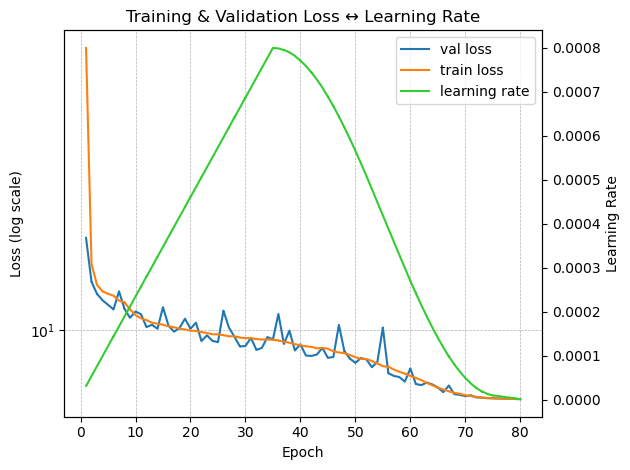

In [16]:
plot_loss_from_log('outputs/run_61/full_A_run.log')

# 62, Supercalo B 
- warmup_epochs       = 35
- cooldown_epochs     = 41
- annihilation_epochs = 4
- max_lr              = 8e-4
- base_lr             = 8e-6

[20.816068, 20.8161, 15.902473, 15.9025, 14.658857, 14.6589, 13.896442, 13.8964, 13.620277, 13.6203, 14.360407, 14.3604, 13.956485, 13.9565, 16.248469, 16.2485, 12.829236, 12.8292, 12.621209, 12.6212, 12.368398, 12.3684, 13.598884, 13.5989, 12.790327, 12.7903, 12.480152, 12.4802, 12.106704, 12.1067, 12.20287, 12.2029, 11.956839, 11.9568, 12.070133, 12.0701, 11.777095, 11.7771, 13.067359, 13.0674, 12.283738, 12.2837, 11.739255, 11.7393, 11.778597, 11.7786, 12.369067, 12.3691, 12.363105, 12.3631, 12.350437, 12.3504, 11.772253, 11.7723, 11.713011, 11.713, 12.465441, 12.4654, 11.712879, 11.7129, 11.395019, 11.395, 11.799504, 11.7995, 11.654422, 11.6544, 11.584525, 11.5845, 12.398362, 12.3984, 13.158551, 13.1586, 12.079402, 12.0794, 11.987253, 11.9873, 13.26101, 13.261, 12.265023, 12.265, 11.248795, 11.2488, 11.664295, 11.6643, 13.666607, 13.6666, 10.715791, 10.7158, 11.334426, 11.3344, 10.707515, 10.7075, 11.317732, 11.3177, 10.726299, 10.7263, 10.717066, 10.7171, 10.671358, 10.6714, 10.43

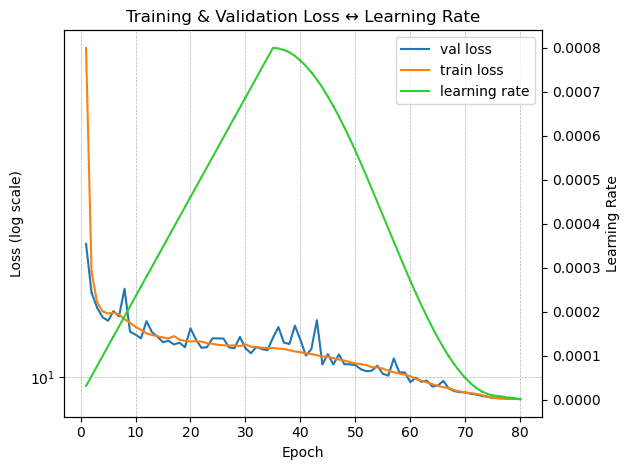

In [17]:
plot_loss_from_log('outputs/run_62/full_B_run.log')

# 63, batchsize = 30k
- warmup_epochs       = 25
- cooldown_epochs     = 51
- annihilation_epochs = 4
- max_lr              = 5e-4
- base_lr             = 8e-6

[25.414767, 25.4148, 16.832252, 16.8323, 14.337923, 14.3379, 13.192521, 13.1925, 12.647155, 12.6472, 12.37351, 12.3735, 12.485506, 12.4855, 12.044239, 12.0442, 12.533614, 12.5336, 11.829253, 11.8293, 12.040625, 12.0406, 11.994676, 11.9947, 11.677561, 11.6776, 13.760477, 13.7605, 10.990159, 10.9902, 11.093206, 11.0932, 10.706453, 10.7065, 11.583314, 11.5833, 10.894254, 10.8943, 10.409998, 10.41, 10.731986, 10.732, 10.488399, 10.4884, 11.721579, 11.7216, 10.616697, 10.6167, 10.992594, 10.9926, 10.759223, 10.7592, 10.114857, 10.1149, 10.162268, 10.1623, 10.096087, 10.0961, 10.270952, 10.271, 10.05044, 10.0504, 9.702139, 9.7021, 9.97362, 9.9736, 9.751976, 9.752, 9.975707, 9.9757, 9.737165, 9.7372, 10.001796, 10.0018, 9.692, 9.692, 9.385753, 9.3858, 9.176744, 9.1767, 9.394177, 9.3942, 9.169151, 9.1692, 10.620463, 10.6205, 9.038827, 9.0388, 9.221042, 9.221, 9.13923, 9.1392, 9.125491, 9.1255, 8.892182, 8.8922, 8.981817, 8.9818, 8.87166, 8.8717, 8.944285, 8.9443, 8.720712, 8.7207, 8.752804, 8.

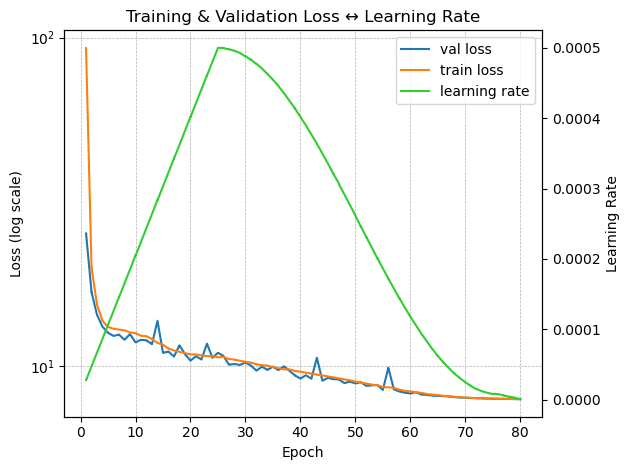

In [18]:
plot_loss_from_log('outputs/run_63/full_A_run.log')

# 64, batchsize = 30k
- warmup_epochs       = 38
- cooldown_epochs     = 38
- annihilation_epochs = 4
- max_lr              = 1e-3
- base_lr             = 8e-6

[23.825858, 23.8259, 16.094978, 16.095, 13.81839, 13.8184, 12.836623, 12.8366, 12.974171, 12.9742, 12.706862, 12.7069, 12.870269, 12.8703, 11.920901, 11.9209, 11.77801, 11.778, 11.702259, 11.7023, 12.186686, 12.1867, 13.375798, 13.3758, 12.135139, 12.1351, 11.143118, 11.1431, 11.932133, 11.9321, 11.015968, 11.016, 10.783775, 10.7838, 11.642904, 11.6429, 11.4889, 11.4889, 10.357801, 10.3578, 10.468853, 10.4689, 10.405852, 10.4059, 11.071364, 11.0714, 10.221638, 10.2216, 10.380061, 10.3801, 10.235963, 10.236, 10.435512, 10.4355, 10.421074, 10.4211, 10.135879, 10.1359, 9.976178, 9.9762, 10.346547, 10.3465, 10.274236, 10.2742, 10.944642, 10.9446, 9.812445, 9.8124, 11.386466, 11.3865, 9.736347, 9.7363, 10.308811, 10.3088, 10.294038, 10.294, 9.91732, 9.9173, 10.614611, 10.6146, 9.493353, 9.4934, 9.500733, 9.5007, 9.584538, 9.5845, 9.684334, 9.6843, 9.454886, 9.4549, 9.735825, 9.7358, 9.292005, 9.292, 9.738653, 9.7387, 9.261337, 9.2613, 9.089987, 9.09, 9.294835, 9.2948, 10.259811, 10.2598, 8.

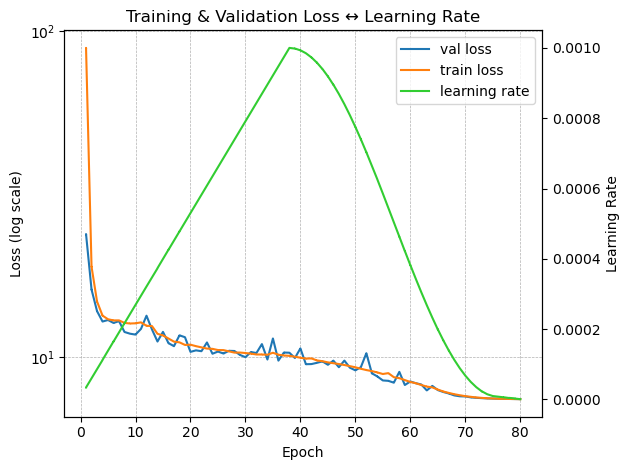

In [19]:
plot_loss_from_log('outputs/run_64/full_A_run.log')

# 65, test convergenza, controllo che non ci sia qualche altro porblema che eviti di convergere allenando in modalita A old school
- batchsize = 10k
- warmup_epochs       = 30
- cooldown_epochs     = 46
- annihilation_epochs = 4
- max_lr              = 8e-4
- base_lr             = 1e-5

[16.486835, 16.4868, 11.430229, 11.4302, 9.820484, 9.8205, 8.934923, 8.9349, 8.2912, 8.2912, 8.74147, 8.7415, 7.554332, 7.5543, 10.178254, 10.1783, 7.931471, 7.9315, 9.235822, 9.2358, 7.199412, 7.1994, 6.408465, 6.4085, 6.490984, 6.491, 6.40904, 6.409, 9.249005, 9.249, 7.620653, 7.6207, 6.087961, 6.088, 6.175481, 6.1755, 6.152251, 6.1523, 8.962002, 8.962, 5.659296, 5.6593, 5.018434, 5.0184, 7.213781, 7.2138, 9.155942, 9.1559, 6.442264, 6.4423, 5.26391, 5.2639, 6.845504, 6.8455, 5.724615, 5.7246, 5.421951, 5.422, 5.518864, 5.5189, 5.214811, 5.2148, 4.7247, 4.7247, 5.722316, 5.7223, 4.773197, 4.7732, 4.612285, 4.6123, 4.755548, 4.7555, 3.958852, 3.9589, 4.732676, 4.7327, 5.28019, 5.2802, 3.766026, 3.766, 3.764533, 3.7645, 5.053721, 5.0537, 3.548439, 3.5484, 3.682842, 3.6828, 3.887174, 3.8872, 2.749168, 2.7492, 3.016952, 3.017, 3.467753, 3.4678, 2.541973, 2.542, 2.732541, 2.7325, 2.166903, 2.1669, 3.168458, 3.1685, 2.538672, 2.5387, 2.456446, 2.4564, 1.493392, 1.4934, 1.781736, 1.7817, 1.

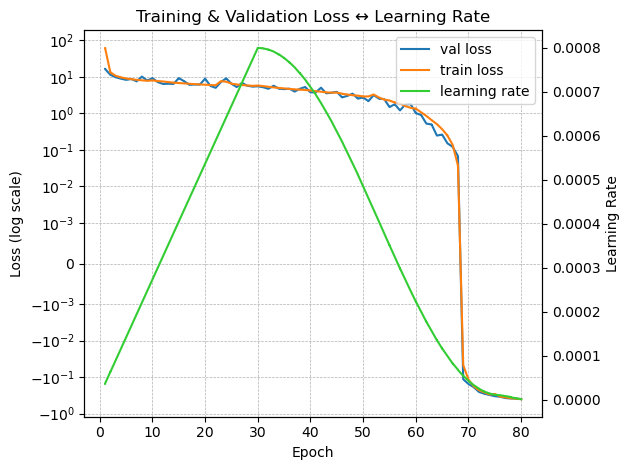

In [20]:
plot_loss_from_log('outputs/run_65/full_A_run.log')

# 66, again supercalo A without fine layer energies. Changed structure, if layer_energies = False, cl is now a 0 array. just to check if the old structure will make the convergence faster. 
- batchsize = 20k (fatser training)
- warmup_epochs       = 30
- cooldown_epochs     = 46
- annihilation_epochs = 4
- max_lr              = 8e-4
- base_lr             = 1e-5

[20.105631, 20.1056, 14.698361, 14.6984, 13.093017, 13.093, 13.251184, 13.2512, 12.417693, 12.4177, 12.929783, 12.9298, 11.530292, 11.5303, 11.347382, 11.3474, 11.305434, 11.3054, 12.492554, 12.4926, 10.941663, 10.9417, 11.042103, 11.0421, 11.214481, 11.2145, 10.924534, 10.9245, 12.373195, 12.3732, 10.584035, 10.584, 10.407391, 10.4074, 11.310951, 11.311, 10.645874, 10.6459, 10.370074, 10.3701, 11.711876, 11.7119, 9.887248, 9.8872, 10.604505, 10.6045, 9.751872, 9.7519, 10.009835, 10.0098, 10.25526, 10.2553, 9.655762, 9.6558, 9.766696, 9.7667, 9.91261, 9.9126, 10.537111, 10.5371, 10.146545, 10.1465, 10.253344, 10.2533, 9.785117, 9.7851, 9.314399, 9.3144, 9.800405, 9.8004, 10.197231, 10.1972, 9.831937, 9.8319, 9.238791, 9.2388, 9.15585, 9.1559, 10.334529, 10.3345, 9.605734, 9.6057, 9.984442, 9.9844, 10.095683, 10.0957, 9.220256, 9.2203, 8.690217, 8.6902, 8.742551, 8.7426, 8.870185, 8.8702, 8.558529, 8.5585, 8.714603, 8.7146, 10.247241, 10.2472, 8.571115, 8.5711, 8.533055, 8.5331, 10.3926

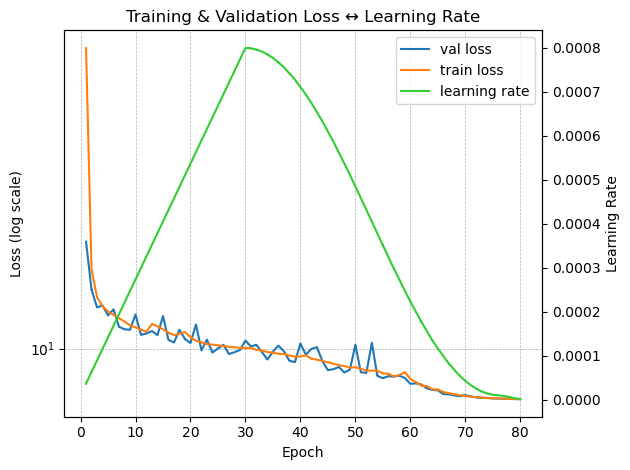

In [21]:
plot_loss_from_log('outputs/run_66/full_A_run.log')

# 67, again supercalo A without fine layer energies, same structure as number 66
- warmup_epochs       = 33
- cooldown_epochs     = 43
- annihilation_epochs = 4
- max_lr              = 2e-3
- base_lr             = 7e-6

[17.927571, 17.9276, 13.905309, 13.9053, 14.765634, 14.7656, 12.20171, 12.2017, 11.720404, 11.7204, 11.425216, 11.4252, 11.897315, 11.8973, 10.804605, 10.8046, 10.675612, 10.6756, 10.636497, 10.6365, 10.253415, 10.2534, 10.195799, 10.1958, 10.283393, 10.2834, 11.360835, 11.3608, 11.966261, 11.9663, 10.637454, 10.6375, 9.773029, 9.773, 10.337122, 10.3371, 9.880781, 9.8808, 10.500055, 10.5001, 9.644691, 9.6447, 11.303557, 11.3036, 10.153677, 10.1537, 10.711038, 10.711, 9.708789, 9.7088, 9.623977, 9.624, 9.810597, 9.8106, 9.675014, 9.675, 9.595637, 9.5956, 10.978374, 10.9784, 9.577791, 9.5778, 9.633713, 9.6337, 9.529729, 9.5297, 10.212963, 10.213, 9.826137, 9.8261, 9.480944, 9.4809, 9.833016, 9.833, 9.405816, 9.4058, 9.435991, 9.436, 8.934656, 8.9347, 9.733308, 9.7333, 9.202894, 9.2029, 10.230421, 10.2304, 9.742342, 9.7423, 10.705593, 10.7056, 9.256675, 9.2567, 9.41712, 9.4171, 9.204333, 9.2043, 9.138994, 9.139, 9.569438, 9.5694, 8.833248, 8.8332, 8.539526, 8.5395, 9.344801, 9.3448, 8.449

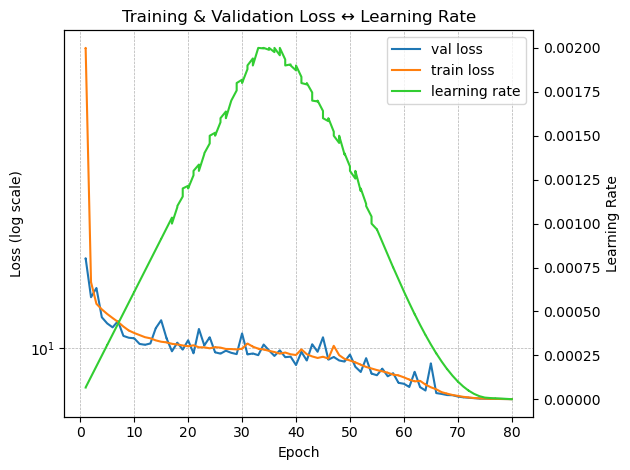

In [22]:
plot_loss_from_log('outputs/run_67/full_A_run.log')

# 68, restored the removal of conditional input if not necessary since the approach of 66 is not workking better. 
- batchsize           = 15k
- warmup_epochs       = 33
- cooldown_epochs     = 43
- annihilation_epochs = 4
- max_lr              = 3e-4
- base_lr             = 5e-6

[23.801267, 23.8013, 16.106957, 16.107, 13.719583, 13.7196, 12.722711, 12.7227, 12.275686, 12.2757, 13.066691, 13.0667, 13.722052, 13.7221, 11.608905, 11.6089, 11.931443, 11.9314, 11.479891, 11.4799, 11.728033, 11.728, 11.095058, 11.0951, 11.030474, 11.0305, 11.041313, 11.0413, 10.945877, 10.9459, 10.560505, 10.5605, 10.572235, 10.5722, 10.535691, 10.5357, 10.639443, 10.6394, 10.23944, 10.2394, 10.144828, 10.1448, 10.250469, 10.2505, 10.678977, 10.679, 10.334184, 10.3342, 12.39904, 12.399, 11.050075, 11.0501, 10.150431, 10.1504, 10.021656, 10.0217, 9.870549, 9.8705, 10.373823, 10.3738, 10.012442, 10.0124, 11.035028, 11.035, 9.912324, 9.9123, 10.152071, 10.1521, 9.657178, 9.6572, 10.261495, 10.2615, 9.734273, 9.7343, 9.766013, 9.766, 9.408901, 9.4089, 9.975735, 9.9757, 9.196284, 9.1963, 10.701921, 10.7019, 9.279262, 9.2793, 9.777854, 9.7779, 9.628267, 9.6283, 9.094224, 9.0942, 9.351881, 9.3519, 8.90018, 8.9002, 8.915949, 8.9159, 8.853692, 8.8537, 9.101593, 9.1016, 8.617591, 8.6176, 8.79

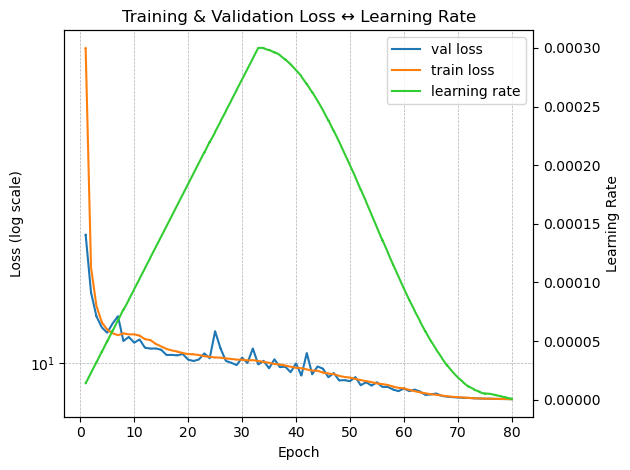

In [23]:
plot_loss_from_log('outputs/run_68/full_A_run.log')

# 69, as 68
- batchsize           = 15k
- warmup_epochs       = 30
- cooldown_epochs     = 46
- annihilation_epochs = 4
- max_lr              = 1e-4
- base_lr             = 2e-6

[46.430573, 46.4306, 21.223015, 21.223, 16.450359, 16.4504, 14.40992, 14.4099, 13.422884, 13.4229, 12.827722, 12.8277, 12.423624, 12.4236, 12.181091, 12.1811, 11.938903, 11.9389, 11.781681, 11.7817, 11.910177, 11.9102, 11.529219, 11.5292, 11.512903, 11.5129, 15.149004, 15.149, 11.592437, 11.5924, 11.358685, 11.3587, 11.273143, 11.2731, 12.567173, 12.5672, 11.177197, 11.1772, 13.881732, 13.8817, 11.145071, 11.1451, 11.015132, 11.0151, 10.919565, 10.9196, 10.811132, 10.8111, 10.674097, 10.6741, 10.651298, 10.6513, 10.567167, 10.5672, 10.582917, 10.5829, 10.601084, 10.6011, 10.51673, 10.5167, 10.602218, 10.6022, 10.633246, 10.6332, 10.540672, 10.5407, 10.361894, 10.3619, 10.266471, 10.2665, 10.3438, 10.3438, 10.166602, 10.1666, 10.266698, 10.2667, 10.094397, 10.0944, 10.134096, 10.1341, 10.03693, 10.0369, 10.099242, 10.0992, 9.947965, 9.948, 9.837836, 9.8378, 9.96412, 9.9641, 9.762769, 9.7628, 9.688201, 9.6882, 9.708052, 9.7081, 9.541611, 9.5416, 9.654477, 9.6545, 9.52772, 9.5277, 9.44640

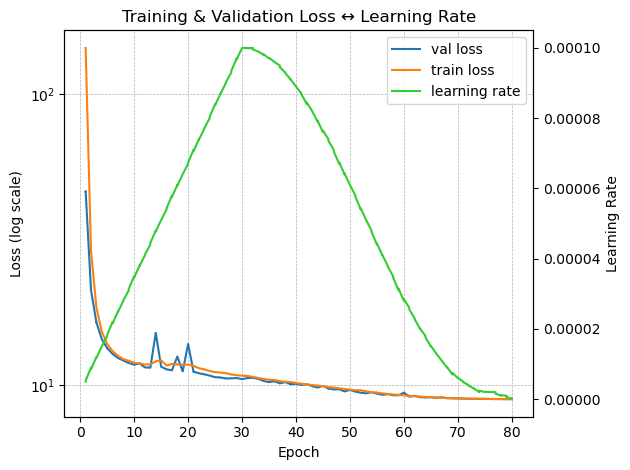

In [24]:
plot_loss_from_log('outputs/run_69/full_A_run.log')

# 70, test supercalo B senza fine layer energies. 
- batchsize = 15k
- warmup_epochs       = 28
- cooldown_epochs     = 48
- annihilation_epochs = 4
- max_lr              = 3e-4
- base_lr             = 4e-6

[30.652248, 30.6522, 20.448481, 20.4485, 17.082884, 17.0829, 15.474336, 15.4743, 14.710176, 14.7102, 14.433345, 14.4333, 14.243308, 14.2433, 13.849894, 13.8499, 13.944607, 13.9446, 13.637043, 13.637, 13.520932, 13.5209, 13.404322, 13.4043, 13.384118, 13.3841, 13.100855, 13.1009, 15.988829, 15.9888, 14.482572, 14.4826, 13.346663, 13.3467, 13.574643, 13.5746, 14.276306, 14.2763, 12.792176, 12.7922, 12.51849, 12.5185, 12.616762, 12.6168, 13.234444, 13.2344, 12.932355, 12.9324, 13.29729, 13.2973, 12.208418, 12.2084, 12.078356, 12.0784, 12.35631, 12.3563, 13.112507, 13.1125, 11.994456, 11.9945, 12.035197, 12.0352, 12.890354, 12.8904, 12.182997, 12.183, 12.135256, 12.1353, 11.695444, 11.6954, 11.712669, 11.7127, 12.228364, 12.2284, 11.445753, 11.4458, 12.035884, 12.0359, 11.553614, 11.5536, 12.147726, 12.1477, 11.246475, 11.2465, 11.383633, 11.3836, 11.336749, 11.3367, 12.478224, 12.4782, 11.056275, 11.0563, 11.119959, 11.12, 10.956751, 10.9568, 10.919524, 10.9195, 11.073323, 11.0733, 10.770

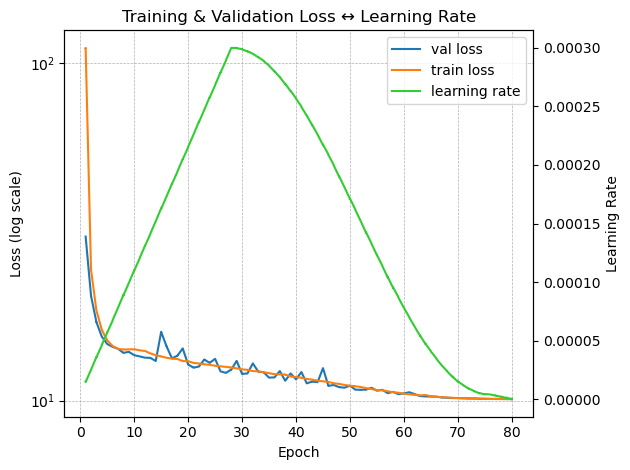

In [25]:
plot_loss_from_log('outputs/run_70/full_B_run.log')

# 71, A
- batchsize = 15k
- warmup_epochs       = 30
- cooldown_epochs     = 46
- annihilation_epochs = 4
- max_lr              = 3e-3
- base_lr             = 1e-5

[14.720609, 14.7206, 13.296846, 13.2968, 12.368254, 12.3683, 12.047641, 12.0476, 11.437085, 11.4371, 11.2885, 11.2885, 10.65361, 10.6536, 10.930297, 10.9303, 10.361152, 10.3612, 10.265599, 10.2656, 9.962746, 9.9627, 10.002012, 10.002, 10.014563, 10.0146, 10.439357, 10.4394, 9.858775, 9.8588, 10.036816, 10.0368, 10.384605, 10.3846, 10.143678, 10.1437, 9.861413, 9.8614, 9.405249, 9.4052, 9.96617, 9.9662, 9.884963, 9.885, 9.781105, 9.7811, 9.357009, 9.357, 10.003472, 10.0035, 9.733813, 9.7338, 10.177738, 10.1777, 9.438602, 9.4386, 10.039264, 10.0393, 9.535004, 9.535, 9.508563, 9.5086, 9.532135, 9.5321, 9.699231, 9.6992, 9.212495, 9.2125, 9.59101, 9.591, 9.177, 9.177, 9.774233, 9.7742, 10.316276, 10.3163, 9.566879, 9.5669, 9.394817, 9.3948, 9.321525, 9.3215, 8.744966, 8.745, 9.334963, 9.335, 9.061487, 9.0615, 8.913837, 8.9138, 9.550903, 9.5509, 8.990946, 8.9909, 8.710382, 8.7104, 8.969956, 8.97, 8.371098, 8.3711, 8.362638, 8.3626, 8.352355, 8.3524, 8.373155, 8.3732, 8.450875, 8.4509, 8.214

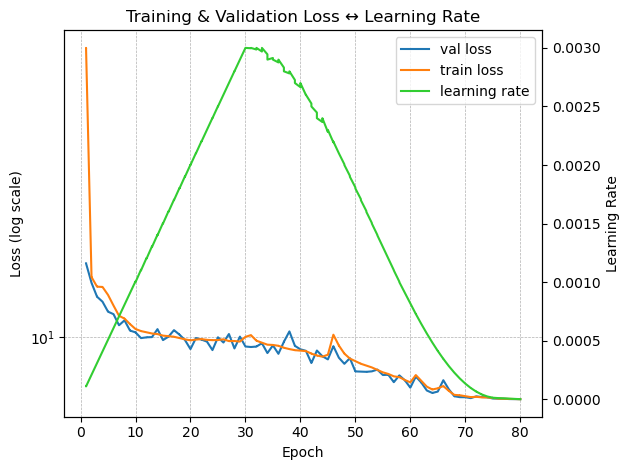

In [26]:
plot_loss_from_log('outputs/run_71/full_A_run.log')

# 72, B
- batchsize = 15k
- warmup_epochs       = 30
- cooldown_epochs     = 46
- annihilation_epochs = 4
- max_lr              = 3e-3
- base_lr             = 2e-5

[17.897376, 17.8974, 15.557859, 15.5579, 16.026495, 16.0265, 14.086743, 14.0867, 13.866784, 13.8668, 13.275566, 13.2756, 13.917418, 13.9174, 12.823321, 12.8233, 12.428846, 12.4288, 12.176413, 12.1764, 12.737813, 12.7378, 12.388661, 12.3887, 12.365251, 12.3653, 12.619024, 12.619, 12.102318, 12.1023, 12.055615, 12.0556, 12.325955, 12.326, 11.759903, 11.7599, 11.926376, 11.9264, 12.771874, 12.7719, 11.89968, 11.8997, 12.295348, 12.2953, 13.165043, 13.165, 14.396836, 14.3968, 11.843181, 11.8432, 11.79517, 11.7952, 11.385359, 11.3854, 11.732889, 11.7329, 11.724505, 11.7245, 13.023465, 13.0235, 12.394689, 12.3947, 11.996688, 11.9967, 11.669462, 11.6695, 12.666395, 12.6664, 13.116378, 13.1164, 12.16997, 12.17, 12.366279, 12.3663, 11.789638, 11.7896, 11.76427, 11.7643, 13.696262, 13.6963, 12.616244, 12.6162, 11.685887, 11.6859, 13.194487, 13.1945, 11.250504, 11.2505, 11.355273, 11.3553, 11.474644, 11.4746, 11.162288, 11.1623, 10.805077, 10.8051, 11.444642, 11.4446, 10.8018, 10.8018, 10.741688,

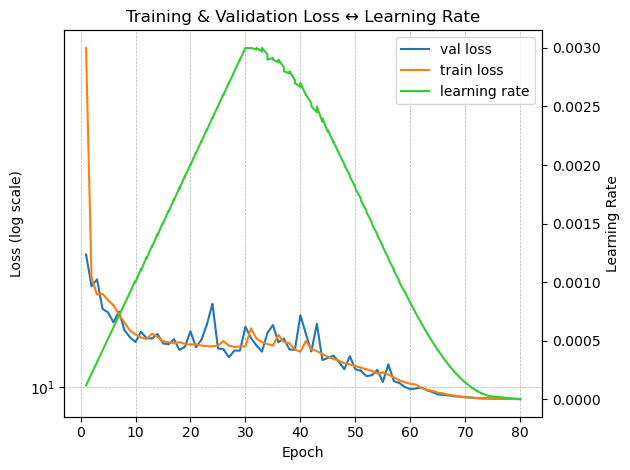

In [27]:
plot_loss_from_log('outputs/run_72/full_B_run.log')

# 73, A
- batchsize = 15k
- warmup_epochs       = 37
- cooldown_epochs     = 37
- annihilation_epochs = 6
- max_lr              = 1e-3
- base_lr             = 8e-6

[18.495181, 18.4952, 13.910256, 13.9103, 12.588622, 12.5886, 12.177511, 12.1775, 11.782252, 11.7823, 12.090865, 12.0909, 11.980583, 11.9806, 13.041963, 13.042, 10.946528, 10.9465, 10.699513, 10.6995, 10.589552, 10.5896, 10.959638, 10.9596, 10.330386, 10.3304, 11.03729, 11.0373, 10.153899, 10.1539, 9.966188, 9.9662, 9.956256, 9.9563, 10.229604, 10.2296, 9.959712, 9.9597, 9.735308, 9.7353, 10.290219, 10.2902, 9.9392, 9.9392, 9.534553, 9.5346, 10.597343, 10.5973, 9.78696, 9.787, 10.414957, 10.415, 10.378753, 10.3788, 9.856134, 9.8561, 9.405155, 9.4052, 9.796526, 9.7965, 10.032344, 10.0323, 9.81801, 9.818, 9.590978, 9.591, 9.737022, 9.737, 9.826625, 9.8266, 9.308857, 9.3089, 11.27903, 11.279, 9.187998, 9.188, 9.534633, 9.5346, 9.01102, 9.011, 9.368912, 9.3689, 8.785449, 8.7854, 9.263794, 9.2638, 8.86858, 8.8686, 10.109138, 10.1091, 9.342886, 9.3429, 8.906542, 8.9065, 8.749309, 8.7493, 8.952176, 8.9522, 9.289933, 9.2899, 9.412849, 9.4128, 8.399199, 8.3992, 9.385824, 9.3858, 8.716647, 8.7166

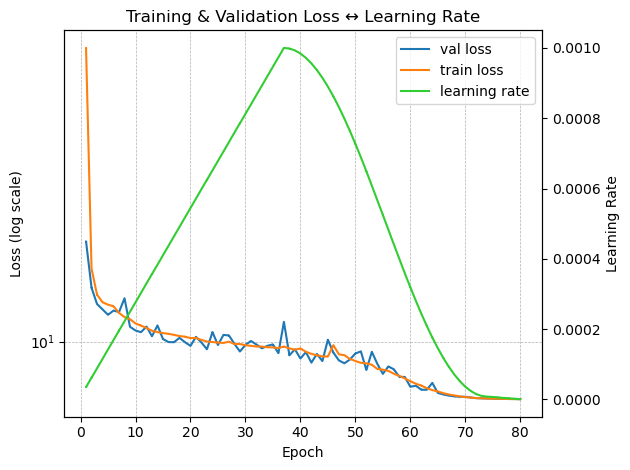

In [28]:
plot_loss_from_log('outputs/run_73/full_A_run.log')

# 74, B
- batchsize = 15k
- warmup_epochs       = 25
- cooldown_epochs     = 51
- annihilation_epochs = 4
- max_lr              = 5e-4
- base_lr             = 5e-6

[26.091126, 26.0911, 18.344415, 18.3444, 15.781985, 15.782, 15.270778, 15.2708, 14.186649, 14.1866, 14.806668, 14.8067, 13.826914, 13.8269, 15.076932, 15.0769, 13.580355, 13.5804, 13.403793, 13.4038, 13.278499, 13.2785, 15.014597, 15.0146, 15.05923, 15.0592, 12.737936, 12.7379, 14.060816, 14.0608, 14.104024, 14.104, 12.615925, 12.6159, 14.401342, 14.4013, 13.126877, 13.1269, 12.219862, 12.2199, 12.98684, 12.9868, 11.95467, 11.9547, 12.092504, 12.0925, 12.208542, 12.2085, 13.782737, 13.7827, 11.786291, 11.7863, 12.159114, 12.1591, 11.854676, 11.8547, 11.930807, 11.9308, 11.768508, 11.7685, 11.974331, 11.9743, 11.714028, 11.714, 12.178983, 12.179, 11.406363, 11.4064, 11.465142, 11.4651, 11.326974, 11.327, 11.206754, 11.2068, 11.680244, 11.6802, 11.349702, 11.3497, 11.387441, 11.3874, 10.960904, 10.9609, 11.189799, 11.1898, 10.839293, 10.8393, 12.203736, 12.2037, 11.007669, 11.0077, 10.991714, 10.9917, 10.843008, 10.843, 10.844733, 10.8447, 11.025755, 11.0258, 10.622615, 10.6226, 10.43508

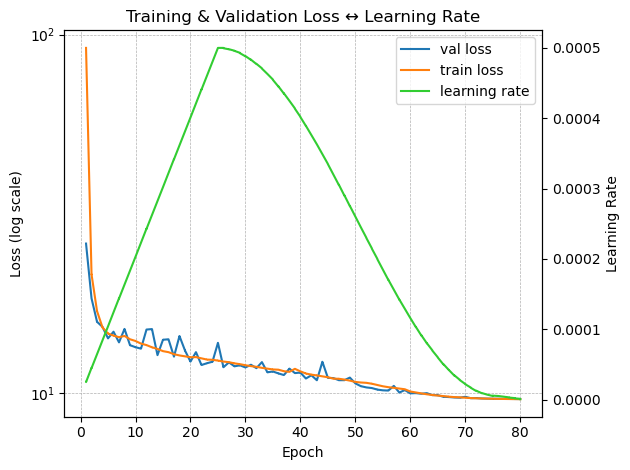

In [29]:
plot_loss_from_log('outputs/run_74/full_B_run.log')

# 75, A
- batchsize = 15k
- warmup_epochs       = 38
- cooldown_epochs     = 38
- annihilation_epochs = 4
- max_lr              = 8e-4
- base_lr             = 9e-6

[18.92931, 18.9293, 14.123918, 14.1239, 13.661507, 13.6615, 12.286983, 12.287, 11.992424, 11.9924, 11.923418, 11.9234, 11.628498, 11.6285, 13.668743, 13.6687, 11.823209, 11.8232, 12.074324, 12.0743, 13.081863, 13.0819, 10.673958, 10.674, 10.519999, 10.52, 11.112071, 11.1121, 10.620699, 10.6207, 10.88072, 10.8807, 10.174397, 10.1744, 10.201469, 10.2015, 9.90869, 9.9087, 10.217502, 10.2175, 10.377754, 10.3778, 10.322878, 10.3229, 10.222372, 10.2224, 9.758657, 9.7587, 10.149426, 10.1494, 10.011305, 10.0113, 9.824672, 9.8247, 10.744842, 10.7448, 11.190607, 11.1906, 9.843195, 9.8432, 9.479003, 9.479, 10.584295, 10.5843, 10.37358, 10.3736, 10.059132, 10.0591, 9.968137, 9.9681, 10.01751, 10.0175, 9.55796, 9.558, 9.831048, 9.831, 9.409162, 9.4092, 10.732177, 10.7322, 9.250413, 9.2504, 9.327139, 9.3271, 9.702978, 9.703, 9.732885, 9.7329, 8.973195, 8.9732, 9.335692, 9.3357, 8.867329, 8.8673, 9.162697, 9.1627, 8.659715, 8.6597, 8.559815, 8.5598, 8.683647, 8.6836, 8.556716, 8.5567, 8.658758, 8.658

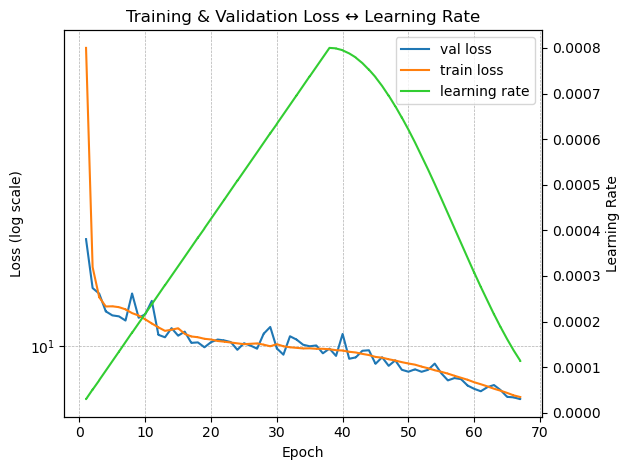

In [30]:
plot_loss_from_log('outputs/run_75/full_A_run.log')

# 76 B, test wiht higher batchsize for regularization and higher LR as in the paper. 
- bathcsize = 40k
- warmup_epochs       = 38
- cooldown_epochs     = 38
- annihilation_epochs = 4
- max_lr              = 2e-3
- base_lr             = 2e-5

[25.065175, 25.0652, 18.425973, 18.426, 16.659658, 16.6597, 15.388436, 15.3884, 14.734881, 14.7349, 14.395221, 14.3952, 14.679631, 14.6796, 15.536135, 15.5361, 14.348991, 14.349, 13.739722, 13.7397, 13.741818, 13.7418, 14.563054, 14.5631, 13.728392, 13.7284, 14.275033, 14.275, 13.201038, 13.201, 13.69327, 13.6933, 13.088309, 13.0883, 14.749927, 14.7499, 13.335742, 13.3357, 13.740172, 13.7402, 12.715292, 12.7153, 12.501952, 12.502, 12.786783, 12.7868, 12.570868, 12.5709, 12.344819, 12.3448, 13.387524, 13.3875, 12.262921, 12.2629, 12.764694, 12.7647, 12.184181, 12.1842, 12.108086, 12.1081, 12.09256, 12.0926, 12.344084, 12.3441, 13.900586, 13.9006, 13.178201, 13.1782, 11.831251, 11.8313, 12.98022, 12.9802, 12.468465, 12.4685, 12.768062, 12.7681, 11.869156, 11.8692, 11.813087, 11.8131, 12.377856, 12.3779, 12.185196, 12.1852, 11.83705, 11.8371, 11.581412, 11.5814, 11.753053, 11.7531, 11.841161, 11.8412, 11.329056, 11.3291, 11.898646, 11.8986, 11.634506, 11.6345, 11.229093, 11.2291, 11.77909

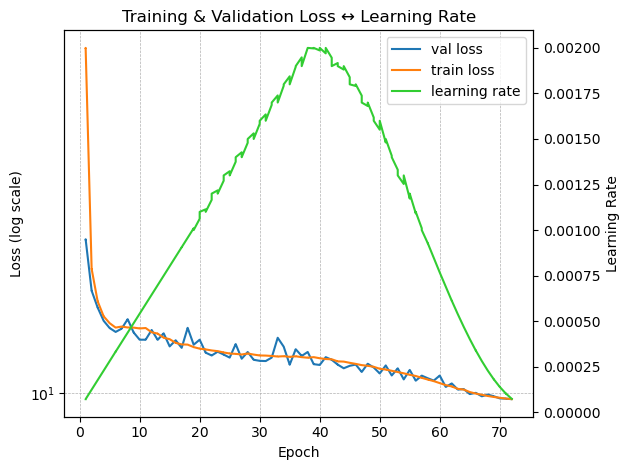

In [31]:
plot_loss_from_log('outputs/run_76/full_B_run.log')